In [ ]:
import folium
import pandas as pd 
from scrapper.AlquilerScrapper import Scrapper
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm




Lectura y limpieza de datos

1. se leen los datos y se transforman en geodataframe añadiendo finromación sobre el barrio en CABA
2. Se borran los datos pertenecientes a barrios con menos de 5 datos
3. Se añade información sobre la cantidad de ambientes, pasando strings a nueros
4. Se añade la columna de area por metro cuadrado "area_m2", transformando los datos de string a numericos. Se borran los datos sin información de area x metro cuadradp
5. Se añade la columna expensas transformando string a numerico. Si no hay información de expensas, se asume que el valor es 0.
6. Se borran los datos con precio de alquiler menor a 100000 pesos

In [24]:
df = pd.read_csv("datos_inmuebles.csv")

df.isna().sum()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1980 non-null   int64  
 1   url               1980 non-null   object 
 2   precio            1980 non-null   object 
 3   expensas          1750 non-null   object 
 4   area_m2           1844 non-null   object 
 5   dormitorios       1444 non-null   object 
 6   antiguedad        1448 non-null   object 
 7   puntaje_arg_prop  1980 non-null   int64  
 8   imagen_path       1973 non-null   object 
 9   image_url         1980 non-null   object 
 10  lat               1923 non-null   float64
 11  lon               1923 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 185.8+ KB


In [25]:
df = df[ df["lat"].notna() & df["lon"].notna() ]
df.info()
df[['lat','lon']].value_counts().head(100)


<class 'pandas.core.frame.DataFrame'>
Index: 1923 entries, 0 to 1979
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1923 non-null   int64  
 1   url               1923 non-null   object 
 2   precio            1923 non-null   object 
 3   expensas          1699 non-null   object 
 4   area_m2           1788 non-null   object 
 5   dormitorios       1408 non-null   object 
 6   antiguedad        1407 non-null   object 
 7   puntaje_arg_prop  1923 non-null   int64  
 8   imagen_path       1916 non-null   object 
 9   image_url         1923 non-null   object 
 10  lat               1923 non-null   float64
 11  lon               1923 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 195.3+ KB


lat         lon       
-34.544895  -58.472244    4
-34.619410  -58.452000    4
-34.607490  -58.500170    4
-34.595300  -58.405130    4
-34.586180  -58.414790    4
                         ..
-34.635090  -58.486530    2
-34.559880  -58.449800    2
-34.555530  -58.462670    2
-34.553870  -58.455360    2
-34.674030  -58.480980    2
Name: count, Length: 100, dtype: int64

<Axes: >

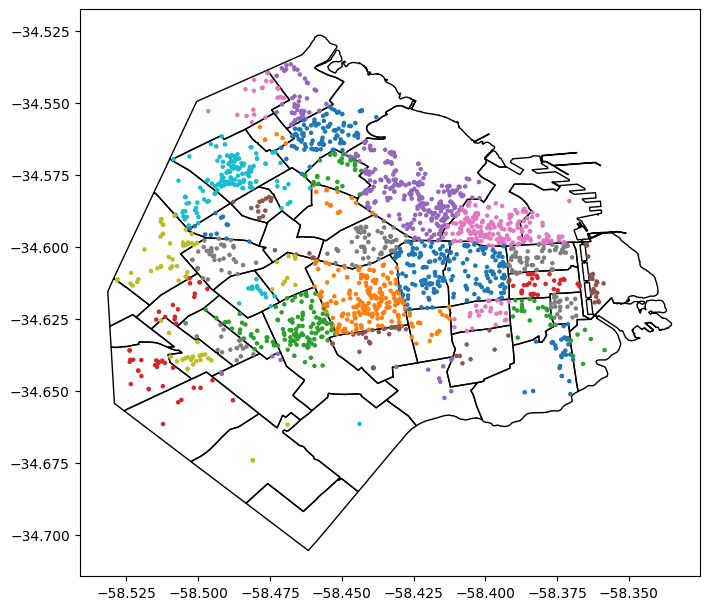

In [26]:


# Barrios
barrios = gpd.read_file("barrios.geojson")

# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf_join = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)
import geopandas as gpd
from shapely.geometry import Point

gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf_join = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf_join.plot(
    ax=ax,
    column='nombre',
    markersize=5,
    legend=False
)


Elimino barrios con menos de 5 datos

In [27]:
gdf_join = gdf_join[
    gdf_join.groupby('nombre')['nombre'].transform('size') >= 5
]


La columna "dormitorios" tiene valores nulos cuando son monoambientes y valores del tipo string "1 dorm. , 2 dorm, etc" cuando no es monoambinete. Por esta razón, se emplea una nueva columna "ambientes" que contabiliza la cantidad de ambientes en función de los dormitorios y lo transforma en un numero entero.

In [28]:
gdf_join['dormitorios'] = gdf_join['dormitorios'].fillna(0)
gdf_join['ambientes'] = gdf_join['dormitorios'].astype(str).str.extract('(\d+)').astype(int) + 1
gdf_join['ambientes']

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


0       2
1       1
2       1
3       1
4       2
       ..
1975    2
1976    3
1977    2
1978    2
1979    4
Name: ambientes, Length: 1910, dtype: int64

Vemos si hay dptos sin infor de superficie cubierta en m^2. En ese caso, rellenamos este dato con la mediana de los departamentos con esa cantidad de ambientes. El resto será descartado.

In [29]:

# convert area_m2 to numeric (extract numbers, handle commas and coercion)
gdf_join['area_m2'] = (
    gdf_join['area_m2']
    .astype(str)
    .str.extract(r'(\d+(?:[\.,]\d+)?)', expand=False)
    .str.replace(',', '.', regex=False)
)
gdf_join['area_m2'] = pd.to_numeric(gdf_join['area_m2'], errors='coerce')

mask = gdf_join['area_m2'].isna() & gdf_join['ambientes'].notna()

gdf_join.loc[mask, 'area_m2'] = (
    gdf_join.groupby('ambientes')['area_m2']
      .transform('median')
      .loc[mask]
)

print("cantidad de nulos en area_m2:", gdf_join['area_m2'].isna().sum())

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en area_m2: 0


In [30]:
gdf_join['expensas'] = (
    gdf_join['expensas']
        .str.extract(r'\$\s*([\d\.]+)')[0]   # toma 350.000
        .str.replace('.', '', regex=False)  # borra separador de miles
        .astype('float')
)


gdf_join['expensas'] = pd.to_numeric(gdf_join['expensas'], errors='coerce')

print("cantidad de nulos en expensas:", gdf_join['expensas'].isna().sum())

gdf_join['expensas'].fillna(0, inplace=True)

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en expensas: 220
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [31]:
gdf_join['precio']

0       $ 620.000 + $350.000 expensas
1       $ 480.000 + $160.000 expensas
2       $ 450.000 + $199.000 expensas
3       $ 750.000 + $195.000 expensas
4       $ 550.000 + $120.000 expensas
                    ...              
1975       USD 750 + $80.000 expensas
1976    $ 815.000 + $112.000 expensas
1977    $ 950.000 + $209.000 expensas
1978     $ 650.000 + $56.500 expensas
1979    $ 950.000 + $250.000 expensas
Name: precio, Length: 1910, dtype: object

In [32]:
print("cantidad de nulos en precio:", gdf_join['precio'].isna().sum())

gdf_join["precio"] = gdf_join["precio"].str.findall(
    r"(?i)(usd|u\$s|\$)\s*([\d\.]+)"
)

print("cantidad de nulos en precio:", gdf_join['precio'].isna().sum())
gdf_join['precio'].where(gdf_join['precio'].isna(), None)



cantidad de nulos en precio: 0
cantidad de nulos en precio: 0


0       None
1       None
2       None
3       None
4       None
        ... 
1975    None
1976    None
1977    None
1978    None
1979    None
Name: precio, Length: 1910, dtype: object

Me quedo solo con el precio del alquiler. Los percios en dolar los transformo a pesos scrapeando el valor de ambitofinanciero
Borro los valores de alquiler menores a $100k por ser demasiado bajos

In [34]:

gdf_join["precio"] = gdf_join["precio"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) >= 1 else (np.nan, np.nan)
)
gdf_join = gdf_join[~gdf_join['precio'].apply(lambda x: pd.isna(x[0]))]

valor_dolar_oficial_venta = pd.read_csv("dolar_hoy.csv").iloc[0]['valor']

gdf_join['precio'] = gdf_join['precio'].apply(
    lambda x: float(x[1].replace('.', '')) * valor_dolar_oficial_venta if x[0].lower() in ['usd', 'u$s'] else float(x[1].replace('.', ''))
)   

gdf_join['precio'] = pd.to_numeric(gdf_join['precio'], errors='coerce')

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [35]:
gdf_join = gdf_join.drop(gdf_join[gdf_join['precio'] <= 100000]['precio'].index)

Columna precio por metro cuadrádo 

In [36]:
gdf_join['precio_m2'] = gdf_join['precio'] / gdf_join['area_m2']


EDA

analicemos la relación entre el precio final y la cantidad de ambientes.
Quiero: tomar una zona con puntos parecidos y luego, para cada conjunto de ambientes estimar la relacion entre el precio y la superficie cubierta.
Si vemos que las tendencias son distintas para cada conjunto con ambientes, luego podría existir una dependencia con la cantidad de ambientes en el precio final. 
Por ejemplo, podría pasar que al tener menos demanda los departamentos con muchos ambientes, estos tiendan a no aumentar tanto el precio en relación a los que tinene menos ambientes en comparación al aumento de precio de tener 1 ambiente a 2 ambientes bajo la misme superficie cubierta.

In [37]:
densidad_naive = (
    gdf_join
    .groupby('nombre')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


nombre
Palermo      251
Caballito    198
Recoleta     143
Almagro      108
Flores       101
dtype: int64

In [38]:
gdf_palermo = gdf_join[ gdf_join['nombre'] == 'Palermo' ]
gdf_caballito = gdf_join[ gdf_join['nombre'] == 'Caballito' ]

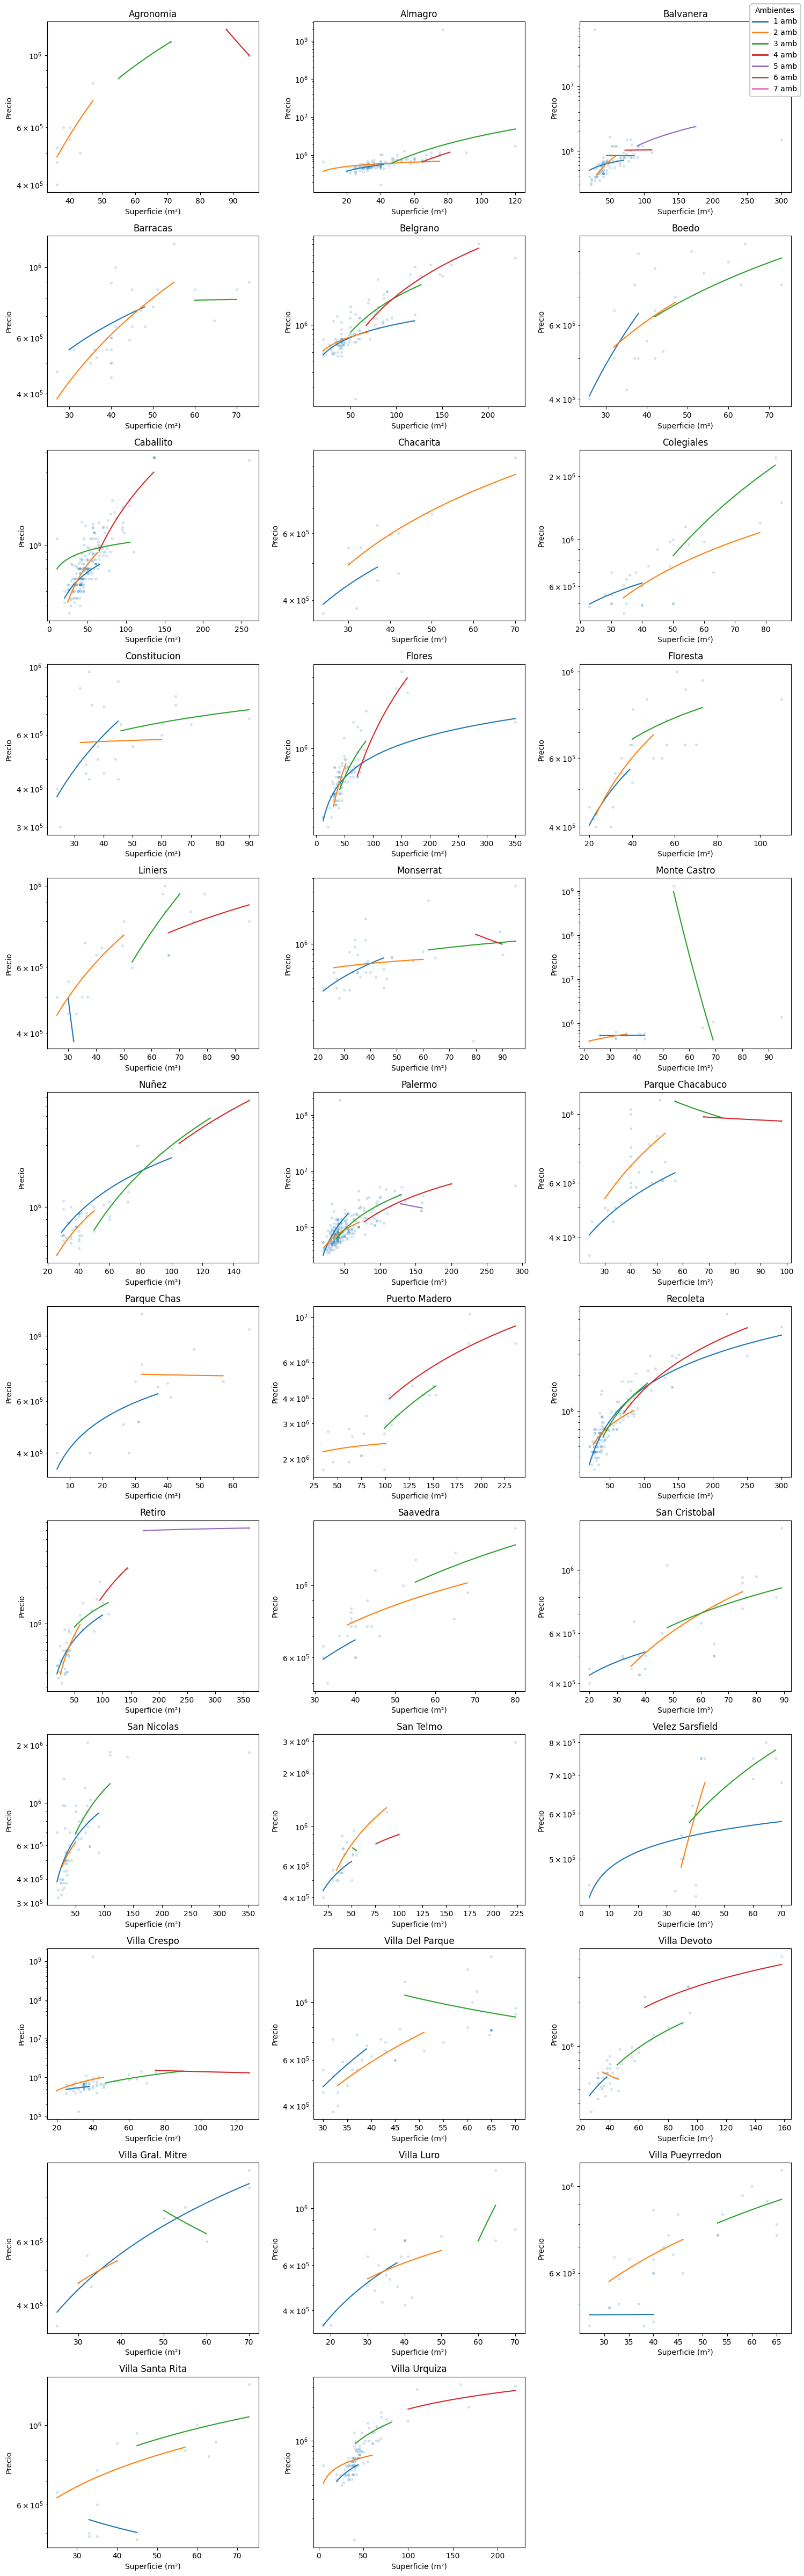

In [106]:
min_obs = 10

barrios = (
    gdf_join
    .groupby('nombre')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf_join['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios):

    gdf_b = gdf_join[gdf_join['nombre'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2'],
        gdf_b['precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(np.log(sub['area_m2']))
        y = np.log(sub['precio'])

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2'].min(),
            sub['area_m2'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(np.log(x_grid))
        )

        ax.plot(
            x_grid,
            np.exp(y_hat),
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )


    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('Precio')
    ax.set_yscale('log')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [41]:
gdf_join['superficie_por_ambientes'] = gdf_join['area_m2'] / gdf_join['ambientes']

# analisis de antiguedad


In [42]:
gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,lat,lon,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes
0,16381059,https://www.argenprop.com/departamento-en-alqu...,620000.00,350000.0,46.00,1 dorm.,NaN,8308,images/16381059.jpg,https://www.argenprop.com/static-content/95018...,-34.598940,-58.412210,POINT (-58.41221 -34.59894),1.0,Almagro,5.0,2,13478.260870,23.00
2,15567556,https://www.argenprop.com/departamento-en-alqu...,450000.00,199000.0,37.00,0,NaN,7942,images/15567556.jpg,https://www.argenprop.com/static-content/65576...,-34.584690,-58.444970,POINT (-58.44497 -34.58469),8.0,Chacarita,15.0,1,12162.162162,37.00
5,6688799,https://www.argenprop.com/departamento-en-alqu...,430000.00,70000.0,30.00,0,NaN,6446,images/6688799.jpg,https://www.argenprop.com/static-content/99788...,-34.565650,-58.440180,POINT (-58.44018 -34.56565),20.0,Palermo,14.0,1,14333.333333,30.00
6,18468803,https://www.argenprop.com/departamento-en-alqu...,1075312.75,203000.0,40.00,0,NaN,6300,images/18468803.jpg,https://www.argenprop.com/static-content/30886...,-34.553856,-58.449883,POINT (-58.44988 -34.55386),4.0,Belgrano,13.0,1,26882.818750,40.00
22,18471385,https://www.argenprop.com/departamento-en-alqu...,800000.00,196000.0,40.00,1 dorm.,NaN,4297,images/18471385.jpg,https://www.argenprop.com/static-content/58317...,-34.563940,-58.441960,POINT (-58.44196 -34.56394),20.0,Palermo,14.0,2,20000.000000,20.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,18641907,https://www.argenprop.com/departamento-en-alqu...,550000.00,103000.0,30.00,0,NaN,25,images/18641907.jpg,https://www.argenprop.com/static-content/70914...,-34.600510,-58.493560,POINT (-58.49356 -34.60051),36.0,Villa Del Parque,11.0,1,18333.333333,30.00
1961,18633271,https://www.argenprop.com/departamento-en-alqu...,1900000.00,390000.0,87.00,2 dorm.,NaN,25,images/18633271.jpg,https://www.argenprop.com/static-content/17233...,-34.585620,-58.422810,POINT (-58.42281 -34.58562),20.0,Palermo,14.0,3,21839.080460,29.00
1968,18498881,https://www.argenprop.com/departamento-en-alqu...,800000.00,227000.0,64.65,2 dorm.,NaN,25,images/18498881.jpg,https://www.argenprop.com/static-content/18889...,-34.634180,-58.485200,POINT (-58.4852 -34.63418),33.0,Velez Sarsfield,10.0,3,12374.323279,21.55
1971,18797664,https://www.argenprop.com/departamento-en-alqu...,500000.00,180000.0,40.00,1 dorm.,NaN,25,images/18797664.jpg,https://www.argenprop.com/static-content/46679...,-34.611590,-58.421710,POINT (-58.42171 -34.61159),1.0,Almagro,5.0,2,12500.000000,20.00


Extraigo datos antiguedad, relleno con la media del barrio cuando no esta precenta (a muchos a estrenar le estoy poniendo mal el dato, se tiene que corregir.)

In [43]:


gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .fillna(
        gdf_join
        .groupby('nombre')['antiguedad']
        .transform('mean')
    )
)

gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,lat,lon,geometry,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes


Variograma por log(precio)

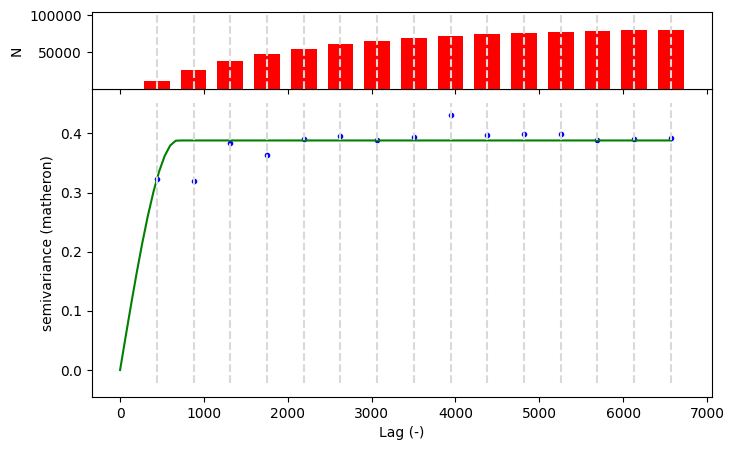

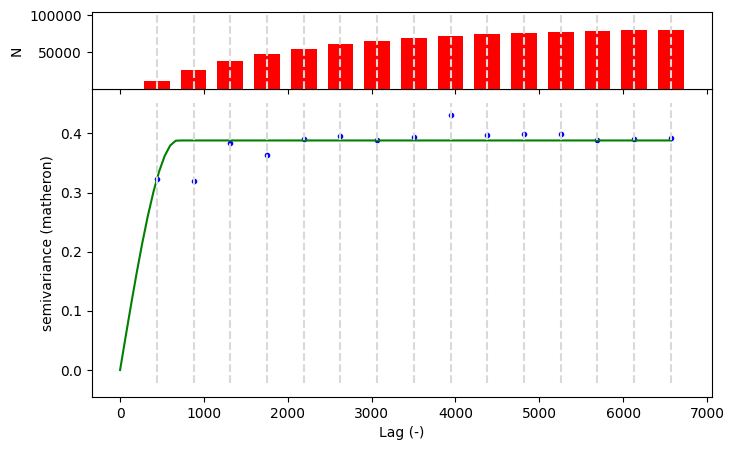

In [44]:


gdf = gdf_join.to_crs(epsg=3857)
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

values = np.log(gdf['precio'].values)

V = Variogram(
    coords,
    values,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag='median',     # o una distancia en metros
    normalize=False
)
V.plot()

# Formulamos y entrenamos modelo

Para cada barrio (si hay datos) vamos a ajustar un modelo geograficamente pesado local, dentro de cada barrio abran multiples modelos para las distintas cantidades 

In [45]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from patsy import dmatrices
from sklearn.preprocessing import StandardScaler
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import copy
from pykrige.ok import OrdinaryKriging


In [46]:


class SpatialKernelPriceModel:
    def __init__(self, gdf: gpd.GeoDataFrame):
        self._check_data_validity(gdf)

        self.data = gdf
        self.bw_ = None
        self.results_ = None
        self.scaler_ = None   # <-- clave

    # ----------------------------
    # Validaciones
    # ----------------------------
    def _check_data_validity(self, data):
        if not isinstance(data, gpd.GeoDataFrame):
            raise TypeError("Input data must be a GeoDataFrame")

        if data.crs is None:
            raise ValueError("GeoDataFrame must have a CRS defined")

        if data.crs.to_epsg() != 3857:
            raise ValueError(
                f"GeoDataFrame CRS must be EPSG:3857, got {data.crs}"
            )

        if not set(data.geometry.geom_type).issubset({"Point"}):
            raise ValueError("Geometry must be Point for spatial kernel models")

    # ----------------------------
    # Fit
    # ----------------------------
    def fit(self, data: gpd.GeoDataFrame):
        self._check_data_validity(data)
        self.data = data

        gdf = data

        # Coordenadas
        coords = np.column_stack([
            gdf.geometry.x,
            gdf.geometry.y
        ])

        # Variable respuesta (log-precio)
        y = np.log(gdf['precio'].values).reshape(-1, 1)

        # Covariables
        X = gdf[
            ['antiguedad', 'ambientes', 'area_m2', 'expensas']
        ].values

        # -------- Normalización --------
        self.scaler_ = StandardScaler()
        X_std = self.scaler_.fit_transform(X)

        # -------- Selección de bandwidth --------
        bw_selector = Sel_BW(
            coords,
            y,
            X_std,
            spherical=False
        )

        bw = bw_selector.search()

        # -------- GWR --------
        self.gwr_ = GWR(
            coords,
            y,
            X_std,
            bw=bw,
            fixed=False,
            kernel='bisquare'
        )

        self.results_ = self.gwr_.fit()
        self.bw_ = bw

        return self.results_

    # ----------------------------
    # Predict
    # ----------------------------
    def predict(self, gdf_new: gpd.GeoDataFrame):
        if self.gwr_ is None or self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        self._check_data_validity(gdf_new)

        coords_new = np.column_stack([
            gdf_new.geometry.x,
            gdf_new.geometry.y
        ])

        X_new = gdf_new[
            ['antiguedad', 'ambientes', 'area_m2', 'expensas']
        ].values

        X_new_std = self.scaler_.transform(X_new)

        gwr_for_pred = copy.deepcopy(self.gwr_)

        preds = gwr_for_pred.predict(
            coords_new,
            X_new_std
        )

        log_preds = preds.predictions.flatten()


        return np.exp(log_preds)


    # ----------------------------
    # Summary
    # ----------------------------
    def summary(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")

        print(self.results_.summary())
        return self.results_.summary()
    
    def results(self):
        if self.results_ is None or self.scaler_ is None:
            raise RuntimeError("Model is not fitted yet")
        return self.results_

In [47]:
gdf = gdf_join.to_crs(epsg=3857)

gdf_train, gdf_test = train_test_split(
    gdf,
    test_size=0.2,
    random_state=42
)

In [48]:

model = SpatialKernelPriceModel(gdf)

model.fit(
    data=gdf_train,
)


In [49]:
model.summary()

Model type                                                         Gaussian
Number of observations:                                                1523
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            372.061
Log-likelihood:                                                   -1087.801
AIC:                                                               2185.601
AICc:                                                              2187.657
BIC:                                                             -10752.507
R2:                                                                   0.433
Adj. R2:                                                              0.431

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [50]:
# Predicción en log (como sale del GWR)
y_test_pred = model.predict(
        gdf_test
)

y_test_true = gdf_test['precio'].values
rmse_price = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred
))

rmse_price



np.float64(347382.322481336)

In [51]:
(y_test_true <= 0).sum()
y_test_true.min(), y_test_true.max()
y_test_pred.min(), y_test_pred.max()

(np.float64(363377.602358773), np.float64(3773838.818580484))

In [52]:
res = model.results()
res.tvalues


array([[ 3.31464788e+02, -1.64485528e+00,  2.44993333e+00,
         3.79337036e+00,  7.51247018e-01],
       [ 3.11678155e+02, -2.22311103e+00,  3.08667206e+00,
         2.86940937e+00,  2.13668703e-03],
       [ 3.71208272e+02, -2.04573961e+00,  2.40576511e+00,
         3.89277493e+00,  3.66824153e-01],
       ...,
       [ 3.56710573e+02, -2.76986107e+00,  2.14094028e+00,
         5.51198411e+00,  1.73584376e-01],
       [ 3.02997797e+02,  5.48202487e-02,  2.82281064e+00,
         6.28730091e+00,  1.37512978e+00],
       [ 3.61418972e+02, -2.83719704e+00,  4.29085444e+00,
         3.89820698e+00,  1.33122209e-01]], shape=(1523, 5))

In [53]:

var_names = ['antiguedad', 'ambientes', 'area_m2', 'expensas']

coefs = pd.DataFrame(
    res.params[:, 1:],   # saco intercepto
    columns=var_names,
    index=gdf_train.index
)

coefs.abs().describe()


,antiguedad,ambientes,area_m2,expensas
count,1523.000000,1523.000000,1523.000000,1523.000000
mean,0.124216,0.153765,0.295941,0.054192
std,0.068361,0.080630,0.132234,0.052309
min,0.000259,0.005645,0.071910,0.000097
25%,0.080691,0.093577,0.183340,0.017718
50%,0.125430,0.133669,0.272251,0.036297
75%,0.155390,0.217610,0.396629,0.074859
max,0.311556,0.380528,0.801290,0.269688


In [54]:
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
tvals = pd.DataFrame(
    res.tvalues[:, 1:],
    columns=var_names,
    index=gdf_train.index
)
significant = np.abs(tvals) > 1.96
significant

(significant).mean() * 100


antiguedad    73.473408
ambientes     57.846356
area_m2       91.398555
expensas      13.854235
dtype: float64

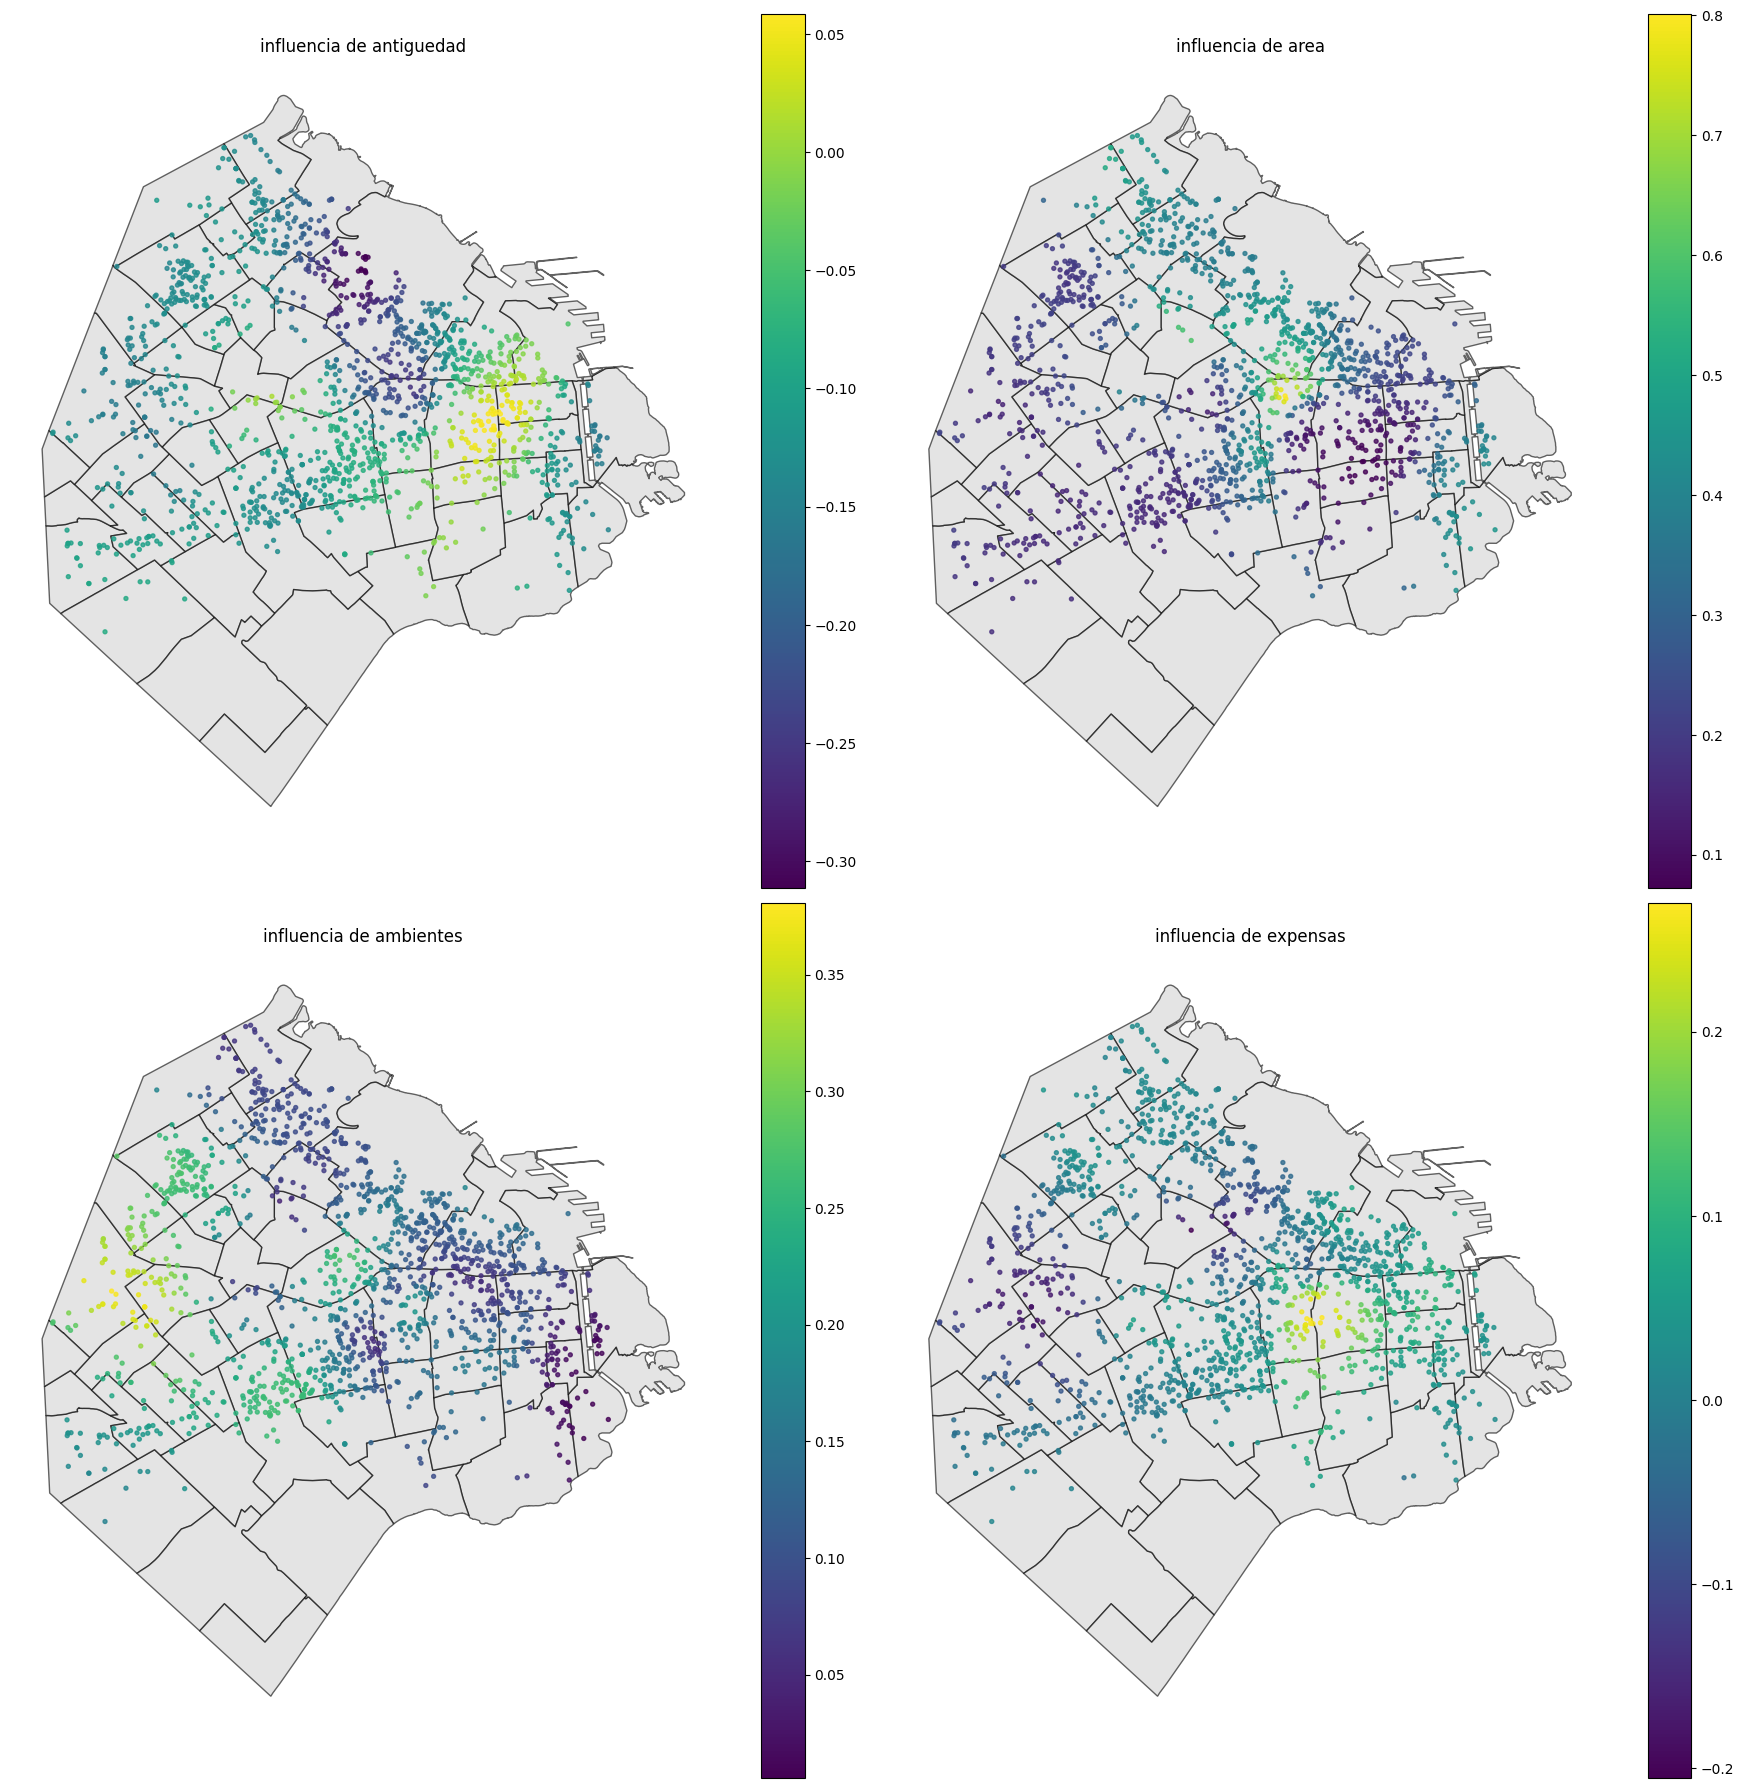

In [98]:
coef_names = [
    "beta_antiguedad", "beta_area", "beta_ambientes",
    "beta_expensas"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 18))
axes = axes.flatten()

barrios = barrios.to_crs(epsg=3857)
gdf = gdf.to_crs(epsg=3857)

for ax, coef in zip(axes, coef_names):

    # ---- fondo: barrios ----
    barrios.plot(
        ax=ax,
        edgecolor="black",
        facecolor="lightgrey",
        alpha=0.6
    )

    # ---- puntos: coeficientes GWR ----
    gdf.plot(
        ax=ax,
        column=coef,
        legend=True,
        markersize=8,
        alpha=0.8
    )

    ax.set_title('influencia de ' + coef.replace("beta_", ""))
    ax.axis("off")

plt.tight_layout()
plt.show()



Kriging en residuos. No aporta casi nada asique conviene no tenerlo en cuenta para reducir la complejidad del modelo.

In [59]:
gdf_train = gdf_train.to_crs(epsg=3857)
gdf_test = gdf_test.to_crs(epsg=3857)

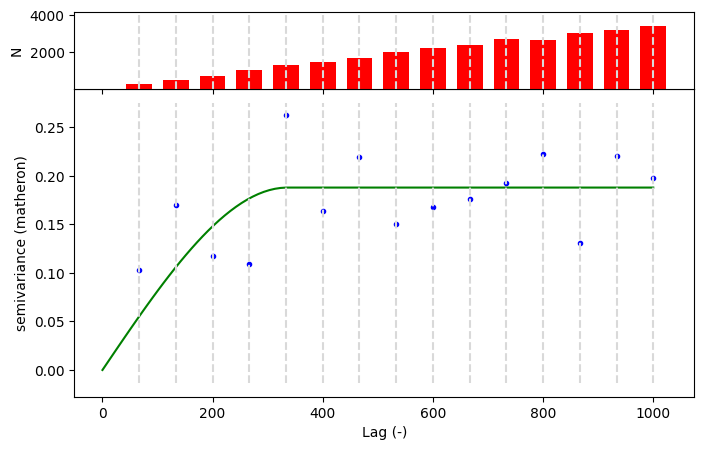

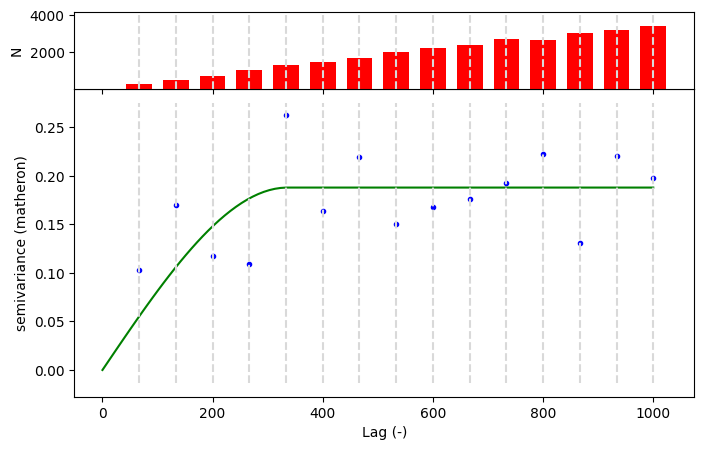

In [86]:

coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])

y_train_true = gdf_train['precio'].values
y_train_pred = model.predict(
        gdf_train
)
residuals = np.log(y_train_true) - np.log(y_train_pred)

V = Variogram(
    coords,
    residuals,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag=1000,     # o una distancia en metros
    normalize=False
)
V.plot()

In [87]:
coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])
coords_test = np.column_stack([
    gdf_test.geometry.x,
    gdf_test.geometry.y
])
sill, range_, _ = V.parameters
nugget = 0.0002  
OK = OrdinaryKriging(
    coords[:,0],
    coords[:,1],
    gdf_train['precio'].values,
    variogram_model='gaussian',
    variogram_parameters=[sill, range_, nugget]
)
z_pred, ss = OK.execute('points', coords_test[:,0], coords_test[:,1])

In [88]:


rmse = np.sqrt(mean_squared_error(
    gdf_test['precio'].values,
    z_pred
))

mae = mean_absolute_error(
    gdf_test['precio'].values,
    z_pred
)

rmse, mae


(np.float64(3364326.6544543807), 3158045.4427599246)

In [89]:
sill, range_, _ = V.parameters
nugget = 0.002  

OK = OrdinaryKriging(
    coords[:,0],
    coords[:,1],
    residuals,
    variogram_model="spherical",
    variogram_parameters=[sill, range_, nugget]
)

z_pred, ss = OK.execute('points', coords_test[:,0], coords_test[:,1])

y_test_pred_model_y_residual_kriging = y_test_pred + np.exp(z_pred)

In [90]:
print("z_pred stats:")
print("min:", z_pred.min())
print("max:", z_pred.max())
print("mean:", z_pred.mean())
print("std:", z_pred.std())

z_pred stats:
min: -0.6888878108102947
max: 0.7323126538393834
mean: -0.004245140558168401
std: 0.09526305212727597


In [91]:

rmse = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
))

mae = mean_absolute_error(
    y_test_true,
    y_test_pred_model_y_residual_kriging
)

rmse, mae

(np.float64(347382.2238595724), 188772.3521511919)

In [92]:
(y_test_pred_model_y_residual_kriging <= 0).sum()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()
y_test_pred_model_y_residual_kriging.min(), y_test_pred_model_y_residual_kriging.max()

(np.float64(363379.14643869473), np.float64(3773839.8175439825))

Local outlier detection con Lisa

In [65]:
from esda.moran import Moran_Local
from libpysal.weights import KNN

gdf.to_crs(epsg=3857)

coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])


w = KNN.from_array(coords, k=8)
w.transform = "r"

y_true = gdf['precio'].values

model_global = SpatialKernelPriceModel(gdf)

model_global.fit(
    data=gdf,
)

y_pred = model_global.predict(
        gdf
)
residuals = y_true - y_pred
lisa = Moran_Local(residuals, w)


In [66]:
outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))


In [67]:
gdf[outliers]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,index_right,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes,beta_area,beta_ambientes,beta_antiguedad,beta_expensas
2,15567556,https://www.argenprop.com/departamento-en-alqu...,450000.0,199000.0,37.0,0,25.222222,7942,images/15567556.jpg,https://www.argenprop.com/static-content/65576...,...,8.0,Chacarita,15.0,1,12162.162162,37.000000,0.485086,0.124915,-0.234876,-0.146928
5,6688799,https://www.argenprop.com/departamento-en-alqu...,430000.0,70000.0,30.0,0,29.194737,6446,images/6688799.jpg,https://www.argenprop.com/static-content/99788...,...,20.0,Palermo,14.0,1,14333.333333,30.000000,0.369011,0.092598,-0.278957,-0.016300
7,18688308,https://www.argenprop.com/departamento-en-alqu...,750000.0,200000.0,36.0,1 dorm.,15.000000,6238,images/18688308.jpg,https://www.argenprop.com/static-content/80388...,...,20.0,Palermo,14.0,2,20833.333333,18.000000,0.399787,0.131087,-0.154097,0.030581
17,18094217,https://www.argenprop.com/departamento-en-alqu...,500000.0,136900.0,32.0,1 dorm.,40.000000,4744,images/18094217.jpg,https://www.argenprop.com/static-content/71249...,...,20.0,Palermo,14.0,2,15625.000000,16.000000,0.431135,0.143407,-0.252742,-0.050568
19,18583518,https://www.argenprop.com/departamento-en-alqu...,850000.0,270000.0,41.0,1 dorm.,56.000000,4601,images/18583518.jpg,https://www.argenprop.com/static-content/81538...,...,28.0,Retiro,1.0,2,20731.707317,20.500000,0.223688,0.111764,0.001190,0.048737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,18673179,https://www.argenprop.com/departamento-en-alqu...,500000.0,100000.0,30.0,0,40.000000,26,images/18673179.jpg,https://www.argenprop.com/static-content/97137...,...,8.0,Chacarita,15.0,1,16666.666667,30.000000,0.583610,0.064380,-0.162972,-0.161346
1945,17355182,https://www.argenprop.com/departamento-en-alqu...,2966380.0,450000.0,78.0,2 dorm.,20.000000,25,images/17355182.jpg,https://www.argenprop.com/static-content/28155...,...,19.0,Nuñez,13.0,3,38030.512821,26.000000,NaN,NaN,NaN,NaN
1950,14107153,https://www.argenprop.com/departamento-en-alqu...,570000.0,140000.0,42.0,0,15.000000,25,images/14107153.jpg,https://www.argenprop.com/static-content/35170...,...,12.0,Flores,7.0,1,13571.428571,42.000000,0.156373,0.258079,-0.128789,-0.015032
1951,18303177,https://www.argenprop.com/departamento-en-alqu...,850000.0,262000.0,70.0,2 dorm.,40.000000,25,images/18303177.jpg,https://www.argenprop.com/static-content/77130...,...,7.0,Caballito,6.0,3,12142.857143,23.333333,0.193874,0.235047,-0.126752,0.008609


In [70]:
gdf_outliers = gdf[outliers]
gdf_outliers['precio_total'] = gdf_outliers['precio'] + gdf_outliers['expensas']
gdf_outliers.sort_values('precio_total')

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,...,nombre,comuna,ambientes,precio_m2,superficie_por_ambientes,beta_area,beta_ambientes,beta_antiguedad,beta_expensas,precio_total
606,3191475,https://www.argenprop.com/departamento-en-alqu...,350000.0,0.0,12.0,0,6.000000,479,images/3191475.jpg,https://www.argenprop.com/static-content/57419...,...,Flores,7.0,1,29166.666667,12.0,0.157567,0.256710,-0.130579,-0.011802,350000.0
517,3842949,https://www.argenprop.com/departamento-en-alqu...,350000.0,0.0,12.0,0,6.000000,512,images/3842949.jpg,https://www.argenprop.com/static-content/94924...,...,Flores,7.0,1,29166.666667,12.0,NaN,NaN,NaN,NaN,350000.0
962,18665329,https://www.argenprop.com/departamento-en-alqu...,480000.0,0.0,24.0,0,30.562500,200,images/18665329.jpg,https://www.argenprop.com/static-content/92356...,...,Flores,7.0,1,20000.000000,24.0,0.156936,0.256746,-0.127886,-0.015857,480000.0
295,17694101,https://www.argenprop.com/departamento-en-alqu...,380000.0,107000.0,20.0,0,27.000000,1000,images/17694101.jpg,https://www.argenprop.com/static-content/10149...,...,Palermo,14.0,1,19000.000000,20.0,0.405510,0.136913,-0.273483,-0.041866,487000.0
1509,18752142,https://www.argenprop.com/departamento-en-alqu...,395000.0,93000.0,27.0,0,40.000000,71,images/18752142.jpg,https://www.argenprop.com/static-content/24125...,...,San Nicolas,1.0,1,14629.629630,27.0,0.173637,0.093099,0.025565,0.094145,488000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705,18039561,https://www.argenprop.com/departamento-en-alqu...,6229398.0,0.0,360.0,4 dorm.,50.000000,350,images/18039561.jpg,https://www.argenprop.com/static-content/16593...,...,Retiro,1.0,5,17303.883333,72.0,0.228017,0.136162,-0.014272,0.047555,6229398.0
205,18515503,https://www.argenprop.com/departamento-en-alqu...,5636122.0,850000.0,230.0,4 dorm.,2.000000,1200,images/18515503.jpg,https://www.argenprop.com/static-content/30551...,...,Belgrano,13.0,5,24504.878261,46.0,0.378538,0.090962,-0.216729,0.003106,6486122.0
1720,18378314,https://www.argenprop.com/departamento-en-alqu...,6674355.0,600000.0,150.0,3 dorm.,26.945946,50,images/18378314.jpg,https://www.argenprop.com/static-content/41387...,...,Nuñez,13.0,4,44495.700000,37.5,0.426736,0.079950,-0.157698,0.024106,7274355.0
527,16768313,https://www.argenprop.com/departamento-en-alqu...,7415950.0,1500000.0,236.0,3 dorm.,12.904762,502,images/16768313.jpg,https://www.argenprop.com/static-content/31386...,...,Puerto Madero,1.0,4,31423.516949,59.0,0.399650,0.021162,-0.165812,0.036382,8915950.0


In [71]:
gdf_ml = gdf_join.to_crs(epsg=4326).copy()

gdf_ml['lon'] = gdf_ml.geometry.x
gdf_ml['lat'] = gdf_ml.geometry.y

gdf_ml['log_precio'] = np.log(gdf_join['precio'])

In [72]:
features = [
    'lat', 'lon',
    'area_m2',
    'ambientes',
    'antiguedad',
    'expensas'
]

target = 'log_precio'

df = gdf_ml[features + [target]].copy()

# eliminar filas con target faltante
df = df.dropna(subset=[target])


In [73]:
from sklearn.impute import SimpleImputer

X = df[features]
y = df[target]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)


In [75]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [372]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))


RF R2: 0.27286055025373324
RF MAE: 0.24327020958430484


In [373]:
import pandas as pd

pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)


area_m2       0.331118
expensas      0.169370
ambientes     0.135191
lat           0.130872
lon           0.124616
antiguedad    0.108834
dtype: float64

In [374]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [375]:
y_pred_xgb = xgb.predict(X_test)

print("XGB R2:", r2_score(y_test, y_pred_xgb))
print("XGB MAE:", mean_absolute_error(y_test, y_pred_xgb))


XGB R2: 0.23715495166539946
XGB MAE: 0.2593276495625976
